# 🧭 Interpreting Contextual Embeddings: Why Raw BERT Geometry Misleads

Static vectors were easy: normalize, use cosine, done. **Contextual** models (BERT, GPT) are trickier. In this notebook we **reproduce on real distilBERT vectors** the problems we saw with cosine similarity interpretation and then show the **fixes** that make similarity meaningful again.

---

## 🧭 Goal

Using `distilbert-base-uncased`, we demonstrate, with code:

- **Curse of dimensionality** — L2 distances concentrate in 768-D.
- **Anisotropy** — even *unrelated* sentences have high cosine; vectors live in a narrow cone.
- **Rogue dimensions** — a few coordinates with huge variance dominate the dot product.
- **Post-hoc fixes** — standardising rogue dims, all-but-the-top, and **whitening** restore contrast.
- **Train it right** — `sentence-transformers` (SBERT) gives an isotropic space *by construction*.

---

## 📌 Table of Contents

1. **Setup & embedding helpers**
2. **Curse of dimensionality**
3. **Anisotropy** (the cone)
4. **Rogue dimensions**
5. **Post-hoc fixes** (standardise / all-but-the-top / whitening)
6. **Train it right** (Sentence-BERT)

## 1. ⚙️ Setup & Embedding Helpers

We load `distilbert-base-uncased` (a 768-dim encoder) and define two helpers: a **token-level** embedding (a word in context) and a **sentence-level** embedding (mean-pooled tokens).

In [1]:
# If sentence-transformers is not installed (needed in section 6):
# %uv add sentence-transformers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import AutoTokenizer, AutoModel, logging as hf_logging
from sklearn.decomposition import PCA

hf_logging.set_verbosity_error()  # quieter model-loading output
sns.set_theme(style="whitegrid")
torch.manual_seed(0)

MODEL = "distilbert-base-uncased"
tok = AutoTokenizer.from_pretrained(MODEL)
model = AutoModel.from_pretrained(MODEL).eval()
print(f"Loaded {MODEL}: hidden size = {model.config.dim}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loaded distilbert-base-uncased: hidden size = 768


In [2]:
def sentence_embedding(sentence):
    """Mean-pooled (over real tokens) sentence embedding, shape (768,)."""
    enc = tok(sentence, return_tensors="pt")
    with torch.no_grad():
        h = model(**enc).last_hidden_state[0]
    mask = enc["attention_mask"][0].bool()
    return h[mask].mean(0).numpy().astype(np.float64)

def token_embedding(sentence, word):
    """Contextual embedding of `word` inside `sentence` (first matching sub-token)."""
    enc = tok(sentence, return_tensors="pt")
    ids = enc["input_ids"][0]
    with torch.no_grad():
        h = model(**enc).last_hidden_state[0]
    wid = tok.convert_tokens_to_ids(word)
    pos = (ids == wid).nonzero().flatten()
    return h[pos[0]].numpy().astype(np.float64) if len(pos) else h.mean(0).numpy().astype(np.float64)

def cos(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

e = sentence_embedding("The cat sat on the mat.")
print("sentence embedding shape:", e.shape)

sentence embedding shape: (768,)


## 2. 🌀 Curse of Dimensionality (768-D)

Same test as for static vectors, now in **768 dimensions**: take many sentence embeddings, compute all pairwise L2 distances, and watch the **contrast ratio** $(d_{\max}-d_{\min})/d_{\min}$ collapse as we add dimensions.

Sentence-embedding matrix: (18, 768)


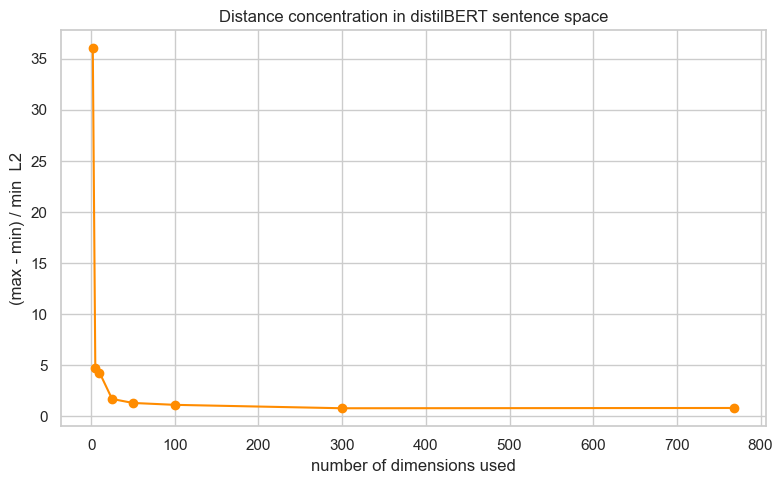

   2 dims -> contrast ratio 36.02
   5 dims -> contrast ratio 4.76
  10 dims -> contrast ratio 4.30
  25 dims -> contrast ratio 1.71
  50 dims -> contrast ratio 1.32
 100 dims -> contrast ratio 1.14
 300 dims -> contrast ratio 0.80
 768 dims -> contrast ratio 0.83


In [3]:
corpus = [
    'The cat sat on the mat.', 'Quantum physics is hard.', 'I ate breakfast quickly.',
    'The stock market fell today.', 'She plays the violin well.', 'Rain is expected tomorrow.',
    'He repaired the old engine.', 'Coffee keeps me awake at night.', 'The river flows north.',
    'Birds migrate south in winter.', 'The committee approved the budget.', 'A rainbow appeared after the storm.',
    'The chef seasoned the soup.', 'Electric cars are getting cheaper.', 'The museum opens at nine.',
    'Children laughed in the playground.', 'The volcano erupted overnight.', 'Investors watched the rates.',
]
E = np.vstack([sentence_embedding(s) for s in corpus])
print('Sentence-embedding matrix:', E.shape)

from scipy.spatial.distance import pdist
def contrast_ratio(M):
    d = pdist(M, metric='euclidean')
    return (d.max() - d.min()) / d.min()

dims = [2, 5, 10, 25, 50, 100, 300, 768]
ratios = [contrast_ratio(E[:, :k]) for k in dims]

plt.figure(figsize=(8, 5))
plt.plot(dims, ratios, 'o-', color='darkorange')
plt.xlabel('number of dimensions used'); plt.ylabel('(max - min) / min  L2')
plt.title('Distance concentration in distilBERT sentence space')
plt.tight_layout(); plt.show()
for k, r in zip(dims, ratios):
    print(f'{k:>4} dims -> contrast ratio {r:.2f}')

### 🔎 What we see

As with static vectors, the L2 **contrast ratio shrinks** with dimension: in 768-D, nearest and farthest sentences sit at almost the same distance. Raw **L2 cannot rank** reliably here.

## 3. 📐 Anisotropy: the Cone

On the slides we claimed contextual vectors **pile into a narrow cone**, so even *unrelated* texts score high cosine (Ethayarajh, 2019). Let's measure the **mean pairwise cosine** of our unrelated sentences. In an isotropic space it should be near **0**.

Mean pairwise cosine of UNRELATED sentences = 0.671
(isotropic space would give ~0.0)


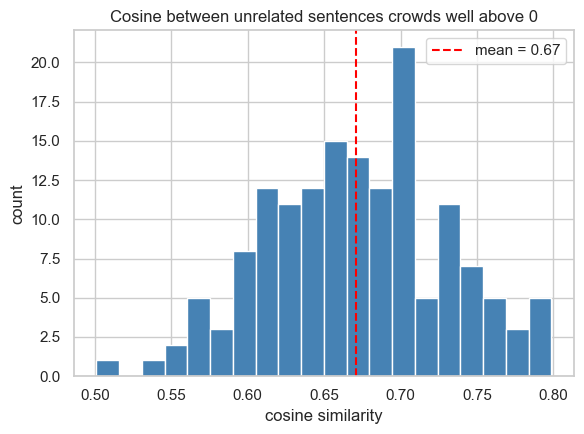

In [4]:
En = E / np.linalg.norm(E, axis=1, keepdims=True)
S = En @ En.T
iu = np.triu_indices(len(corpus), k=1)
mean_cos = S[iu].mean()
print(f'Mean pairwise cosine of UNRELATED sentences = {mean_cos:.3f}')
print('(isotropic space would give ~0.0)')

plt.figure(figsize=(6, 4.5))
plt.hist(S[iu], bins=20, color='steelblue', edgecolor='white')
plt.axvline(mean_cos, color='red', ls='--', label=f'mean = {mean_cos:.2f}')
plt.xlabel('cosine similarity'); plt.ylabel('count')
plt.title('Cosine between unrelated sentences crowds well above 0')
plt.legend(); plt.tight_layout(); plt.show()

In [5]:
# Word-level too: even clearly unrelated words score ~0.5, related ones only a bit higher
word_pairs = [('cat', 'The cat sat on the mat.', 'dog', 'The dog ran in the park.'),
              ('cat', 'The cat sat on the mat.', 'car', 'I bought a new car today.'),
              ('movie', 'I loved that movie.', 'weather', 'The weather is cold.')]
for w1, s1, w2, s2 in word_pairs:
    c = cos(token_embedding(s1, w1), token_embedding(s2, w2))
    print(f'cos({w1:<8}, {w2:<8}) = {c:.3f}')

cos(cat     , dog     ) = 0.804
cos(cat     , car     ) = 0.503
cos(movie   , weather ) = 0.456


### 🔎 What we see

Unrelated sentences average a cosine **far above 0** (~0.6-0.7), and unrelated *words* still score ~0.5. The usable range is **squeezed into a narrow band near 1**, so cosine has little **contrast** left to separate similar from dissimilar. That is the cone.

## 4. 🚩 Rogue Dimensions

Why is the space anisotropic? A big culprit (Timkey & van Schijndel, 2021): a **handful of dimensions** have variance orders of magnitude larger than the rest and **dominate the dot product**. Let's find them in distilBERT's token embeddings.

Top-5 dimensions by std:
  dim 180: std = 3.68
  dim 752: std = 2.46
  dim 308: std = 2.14
  dim 205: std = 1.44
  dim 273: std = 1.38
Median dim std = 0.306
Ratio (top / median) = 12.0x


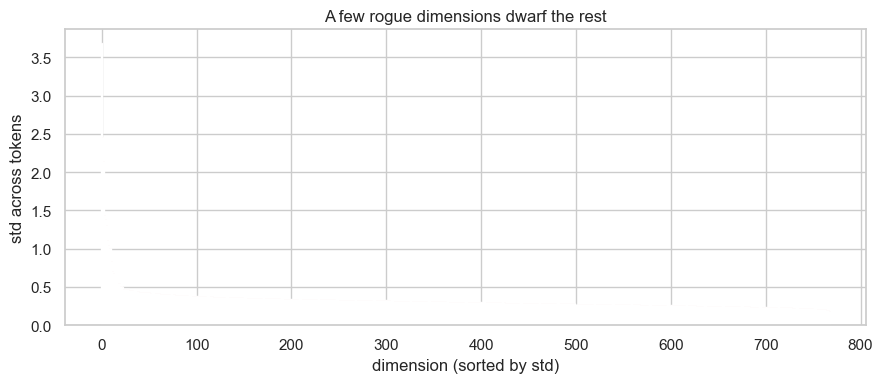

In [6]:
# Collect many token embeddings and look at per-dimension standard deviation
token_vecs = []
for s in corpus:
    enc = tok(s, return_tensors='pt')
    with torch.no_grad():
        h = model(**enc).last_hidden_state[0]
    token_vecs.append(h.numpy())
T = np.vstack(token_vecs).astype(np.float64)
stds = T.std(axis=0)
order = np.argsort(stds)[::-1]

print('Top-5 dimensions by std:')
for d in order[:5]:
    print(f'  dim {d:>3}: std = {stds[d]:.2f}')
print(f'Median dim std = {np.median(stds):.3f}')
print(f'Ratio (top / median) = {stds[order[0]] / np.median(stds):.1f}x')

plt.figure(figsize=(9, 4))
plt.bar(range(len(stds)), np.sort(stds)[::-1], color='crimson')
plt.xlabel('dimension (sorted by std)'); plt.ylabel('std across tokens')
plt.title('A few rogue dimensions dwarf the rest')
plt.tight_layout(); plt.show()

In [7]:
# Toy illustration of WHY one big dimension wrecks cosine (the slide example)
u = np.array([50.0, 1.0, 0.0])
v = np.array([50.0, 0.0, 1.0])
print(f'u = {u},  v = {v}')
print(f'cos(u, v) with the rogue dim   = {cos(u, v):.4f}  (looks near-identical)')
print(f'cos(u, v) WITHOUT dim 0        = {cos(u[1:], v[1:]):.4f}  (correctly orthogonal)')

u = [50.  1.  0.],  v = [50.  0.  1.]
cos(u, v) with the rogue dim   = 0.9996  (looks near-identical)
cos(u, v) WITHOUT dim 0        = 0.0000  (correctly orthogonal)


### 🔎 What we see

A single dimension carries a standard deviation **~12x the median** (dim 180: 3.7 vs median 0.31). Because the dot product sums $u_i v_i$, a coordinate with values around 50 contributes ~2500 while a meaningful dim contributes a fraction — it **drowns the signal** and pulls every cosine toward 1. The toy example makes the mechanism explicit.

## 5. 🔧 Post-hoc Fixes

Three ways to repair a **pretrained** model's geometry at inference, no retraining. We judge each with **two** metrics:
- **Isotropy** — mean pairwise cosine of unrelated sentences (closer to 0 = better).
- **Separation gap** — mean cosine of *related* pairs minus *unrelated* pairs, on held-out labelled pairs (higher = better discrimination).

The methods:
- **Standardise dimensions** (Timkey & van Schijndel): $v'_i = (v_i - \mu_i)/\sigma_i$ — down-weights high-variance rogue dims.
- **All-but-the-top** (Mu & Viswanath): subtract the mean, project out the top-$D$ PCs.
- **Whitening** (Su et al.): $x' = (x-\mu)\,W$, $W = U\Lambda^{-1/2}$ from $\Sigma = U\Lambda U^\top$ — zero mean, identity covariance.

In [8]:
def mean_offdiag_cos(M):
    """Mean cosine over all unique pairs (isotropy proxy; closer to 0 = better)."""
    Mn = M / np.linalg.norm(M, axis=1, keepdims=True)
    return (Mn @ Mn.T)[np.triu_indices(len(M), 1)].mean()

# --- The three transforms, FIT on the corpus E -------------------------------
mu, sigma = E.mean(axis=0), E.std(axis=0)

def standardise(v):       # A. per-dimension standardisation (Timkey & van Schijndel)
    return (v - mu) / sigma

_abtt_comps = PCA(n_components=3, random_state=0).fit(E - mu).components_
def all_but_the_top(v):   # B. remove top-3 PCs (Mu & Viswanath)
    vc = v - mu
    return vc - (vc @ _abtt_comps.T @ _abtt_comps)

_cov = np.cov(E - mu, rowvar=False)
_U, _L, _ = np.linalg.svd(_cov)
_W = _U @ np.diag(1.0 / np.sqrt(_L + 1e-6))
def whiten(v):            # C. whitening (Su et al.)
    return (v - mu) @ _W

FIXES = {'raw': lambda v: v, 'standardised': standardise,
         'all-but-the-top': all_but_the_top, 'whitening': whiten}

# --- Metric 1: isotropy (mean pairwise cosine on the corpus) -----------------
iso = {name: mean_offdiag_cos(np.vstack([f(e) for e in E])) for name, f in FIXES.items()}

# --- Metric 2: does it DISCRIMINATE? Separation gap on held-out pairs --------
# Labelled pairs the corpus never saw; gap = mean(cos related) - mean(cos unrelated).
related = [('A man is playing a guitar.', 'Someone plays a musical instrument.'),
           ('The film was fantastic.', 'I really enjoyed the movie.'),
           ('A dog runs in the park.', 'A puppy is running outside.'),
           ('She is cooking dinner.', 'A woman prepares a meal.')]
unrelated = [('A man is playing a guitar.', 'The stock market fell sharply.'),
             ('The film was fantastic.', 'The recipe needs more salt.'),
             ('A dog runs in the park.', 'Quantum computing is complex.'),
             ('She is cooking dinner.', 'The train arrives at noon.')]

def pair_cos(a, b, f):
    va, vb = f(sentence_embedding(a)), f(sentence_embedding(b))
    return cos(va, vb)

def separation_gap(f):
    r = np.mean([pair_cos(a, b, f) for a, b in related])
    u = np.mean([pair_cos(a, b, f) for a, b in unrelated])
    return r, u, r - u

summary = pd.DataFrame({
    'mean_cos_unrelated': {n: iso[n] for n in FIXES},
    'cos_related':   {n: separation_gap(f)[0] for n, f in FIXES.items()},
    'cos_unrelated': {n: separation_gap(f)[1] for n, f in FIXES.items()},
    'separation_gap': {n: separation_gap(f)[2] for n, f in FIXES.items()},
}).round(3)
summary

,mean_cos_unrelated,cos_related,cos_unrelated,separation_gap
raw,0.671,0.849,0.647,0.203
standardised,-0.058,0.514,-0.013,0.527
all-but-the-top,-0.057,0.489,-0.019,0.508
whitening,-0.059,0.459,0.009,0.450


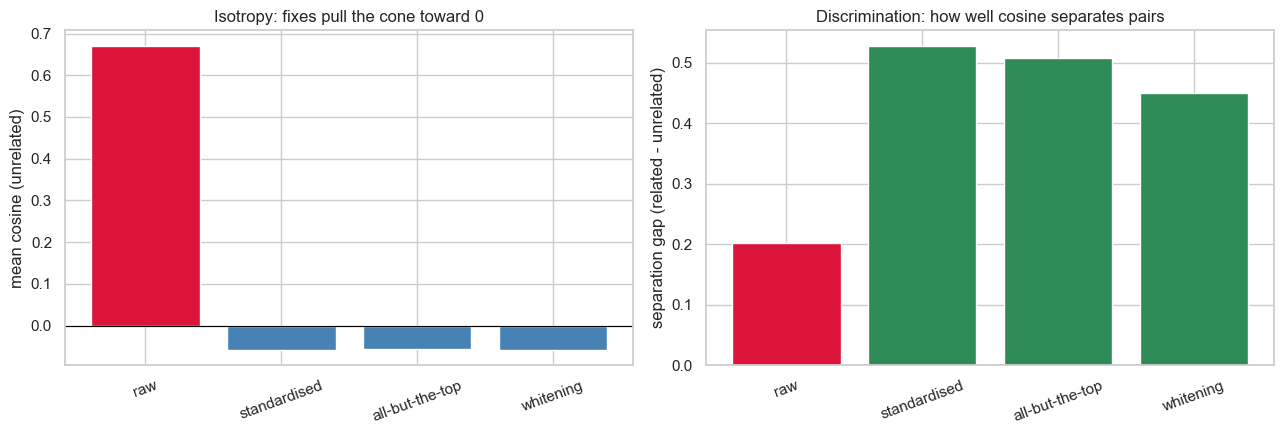

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
names = list(FIXES.keys())

# Left: isotropy (mean cosine of unrelated pairs -> closer to 0 is better)
iso_vals = [summary.loc[n, 'mean_cos_unrelated'] for n in names]
ax[0].bar(names, iso_vals, color=['crimson' if n == 'raw' else 'steelblue' for n in names])
ax[0].axhline(0, color='black', lw=0.8)
ax[0].set(ylabel='mean cosine (unrelated)', title='Isotropy: fixes pull the cone toward 0')
ax[0].tick_params(axis='x', rotation=20)

# Right: discrimination (separation gap = related - unrelated -> higher is better)
gap_vals = [summary.loc[n, 'separation_gap'] for n in names]
ax[1].bar(names, gap_vals, color=['crimson' if n == 'raw' else 'seagreen' for n in names])
ax[1].set(ylabel='separation gap (related - unrelated)', title='Discrimination: how well cosine separates pairs')
ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

### 🔎 What we see

Two metrics tell complementary stories:

- **Isotropy (left).** All three fixes collapse the mean cosine of unrelated sentences from **~0.67** down to **~0** (a touch negative — expected, since centering on a small sample makes the vectors mildly anti-correlated). On this metric the three fixes look **equally good** — mean cosine *saturates*, so it can't rank them.
- **Discrimination (right).** The honest test is the **separation gap** — how far apart *related* and *unrelated* pairs end up. Here raw distilBERT is clearly worst (gap ~0.2: related 0.85 vs unrelated 0.65, barely separable), and every fix roughly **doubles** the gap. They are close to one another, so we do **not** claim one strictly beats the others on this tiny set.

> 🧠 **Why two metrics?** Pushing the mean cosine to 0 (isotropy) is necessary but not sufficient — what we actually care about is whether *related* pairs still score higher than *unrelated* ones. The separation gap measures that directly, and it's the metric that exposes how poor the **raw** space is.

## 6. 🎓 Train It Right: Sentence-BERT

Post-hoc fixes patch a model that was never trained for similarity. The alternative is to **train the geometry directly**: Sentence-BERT / SimCSE fine-tune with a contrastive / siamese objective so that **output cosine already matches semantic similarity** — no whitening needed.

In [10]:
from sentence_transformers import SentenceTransformer
sbert = SentenceTransformer('all-MiniLM-L6-v2')

E_sbert = sbert.encode(corpus, normalize_embeddings=True)
print(f'SBERT mean pairwise cosine (unrelated) = {mean_offdiag_cos(E_sbert):+.3f}')
print(f'(compare: raw distilBERT = {summary.loc["raw", "mean_cos_unrelated"]:+.3f})')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

SBERT mean pairwise cosine (unrelated) = +0.052
(compare: raw distilBERT = +0.671)


SBERT       related=+0.675  unrelated=-0.014  separation_gap=+0.688
raw distilBERT (for reference)                          gap=+0.203


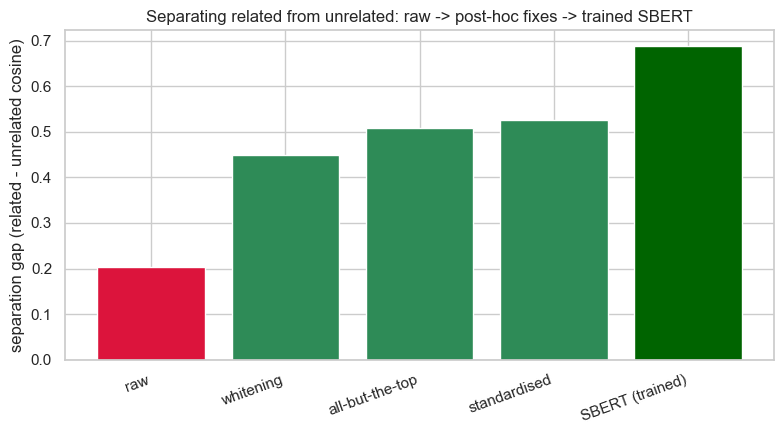

In [11]:
# Does SBERT separate related from unrelated -- on the SAME labelled pairs?
def sbert_cos(a, b):
    ea, eb = sbert.encode([a, b], normalize_embeddings=True)
    return float(ea @ eb)

sb_r = np.mean([sbert_cos(a, b) for a, b in related])
sb_u = np.mean([sbert_cos(a, b) for a, b in unrelated])
print(f'SBERT       related={sb_r:+.3f}  unrelated={sb_u:+.3f}  separation_gap={sb_r - sb_u:+.3f}')
print(f'raw distilBERT (for reference)                          gap={summary.loc["raw", "separation_gap"]:+.3f}')

# Final picture: separation gap from worst (raw) to best (trained-right SBERT)
gaps = {'raw': summary.loc['raw', 'separation_gap'],
        'standardised': summary.loc['standardised', 'separation_gap'],
        'all-but-the-top': summary.loc['all-but-the-top', 'separation_gap'],
        'whitening': summary.loc['whitening', 'separation_gap'],
        'SBERT (trained)': sb_r - sb_u}
plt.figure(figsize=(8, 4.5))
order = sorted(gaps, key=gaps.get)
colors = ['crimson' if k == 'raw' else ('darkgreen' if 'SBERT' in k else 'seagreen') for k in order]
plt.bar(order, [gaps[k] for k in order], color=colors)
plt.ylabel('separation gap (related - unrelated cosine)')
plt.title('Separating related from unrelated: raw -> post-hoc fixes -> trained SBERT')
plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()

### 🔎 What we see

The final bar chart ranks every approach by **separation gap**:

- **raw distilBERT** sits at the bottom (~0.2) — related and unrelated pairs are nearly on top of each other.
- **post-hoc fixes** (standardise / all-but-the-top / whitening) roughly **double** the gap on a frozen model, no retraining.
- **SBERT** wins by a wide margin (~0.7): unrelated pairs drop to ~0, related pairs stay high. Its mean cosine on unrelated text is also ~0 — the cone is gone.

Training the objective *for* cosine similarity (SBERT / SimCSE) fixes the geometry **by construction**, which is why it beats every post-hoc patch.

## ✅ Conclusion

On real distilBERT vectors we reproduced the contextual-embedding story from the slides, and verified the fixes:

| Problem | Evidence | Fix |
|---|---|---|
| Curse of dimensionality | L2 contrast ratio collapses in 768-D (36 → 0.8) | use angle, not raw L2 |
| Anisotropy (cone) | unrelated sentences avg cosine ~0.67 | whitening / standardise |
| Rogue dimensions | top dim std ~12x median (3.7 vs 0.31) | drop / standardise dims |
| Raw geometry unreliable | separation gap only ~0.2 (related ≈ unrelated) | post-hoc **or** train right |
| Post-hoc fixes | gap roughly doubles to ~0.45–0.53 | standardise / all-but-the-top / whitening |
| Trained-right space | SBERT gap ~0.69, mean cosine ~0 | Sentence-BERT / SimCSE |

**Bottom line:** never trust raw contextual cosine blindly. Either **repair the geometry** (standardise / all-but-the-top / whitening) or use a model **trained so cosine is meaningful** (SBERT/SimCSE).